In [1]:
# GOAL: maximize likelihood of the data w.r.t. model parameters (statistical modeling)
# equivalent to maximizing the log likelihood (because log is monotonic)
# equivalent to minimizing the negative log likelihood
# equivalent to minimizing the average negative log likelihood

# log(a*b*c) = log(a) + log(b) + log(c)

In [2]:
words = open('isimler.txt', 'r').read().splitlines()

In [3]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
#bigran_counttan aldım direkt
chars = sorted(list(set(''.join(words)))) #alfabeyi elde etmek için
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [5]:
xs, ys = [], []

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        # print(ch1, ch2, ix1, ix2)
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

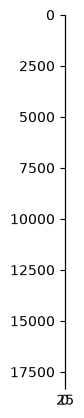

In [6]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=len(stoi)).float()
xenc.shape #torch.Size([5, 27]) #cunku emma xs = [0, 5, 13, 13, 1] . bunu sutun vektoru yapıp 27 sutunlu bi vektör yapıyor normalde hangi sayıya denk geliyosa orayı 1 yapıyor gerisi 0 oluyor.
plt.imshow(xenc)

In [7]:
W = torch.randn((len(stoi), len(stoi)), requires_grad=True)

In [8]:
xenc[3] @ W == W[xs[3]]

tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True])

In [9]:
logits = xenc @ W # log-counts
counts = logits.exp() # equivelent N
probs = counts / counts.sum(1, keepdim=True) # keepdim broadcasting mevzusu

loss = -probs[torch.arange(ys.shape[0]), ys].log().mean() # yine negative log likelihood, değişen tek şey probsun nerden geldiği: count modelde tablodan, burda W matrisinden

loss

tensor(3.8696, grad_fn=<NegBackward0>)

In [10]:
xs, ys = [], []
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples: ', num)

# initialize the 'network'
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((len(stoi), len(stoi)), generator=g, requires_grad=True)

number of examples:  18113


In [19]:
# gradient descent
for k in range(300):
  
  # forward pass
  xenc = F.one_hot(xs, num_classes=len(stoi)).float() # input to the network: one-hot encoding
  logits = xenc @ W # predict log-counts
  counts = logits.exp() # counts, equivalent to N
  probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
  loss = -probs[torch.arange(num), ys].log().mean() + 0.01 * (W**2).mean() # L2 regularization
  print(loss.item())
  
  # backward pass
  W.grad = None # set to zero the gradient
  loss.backward()
  
  # update
  W.data += -50 * W.grad

#output: 2.4827287197113037

2.3932249546051025
2.3932244777679443
2.393224000930786
2.393224000930786
2.393223524093628
2.393223285675049
2.3932228088378906
2.3932225704193115
2.3932220935821533
2.393221855163574
2.393221378326416
2.393221139907837
2.3932206630706787
2.3932204246520996
2.3932201862335205
2.3932199478149414
2.393219470977783
2.393219232559204
2.393218755722046
2.393218517303467
2.393218517303467
2.3932180404663086
2.3932175636291504
2.393217086791992
2.393216848373413
2.393216609954834
2.393216133117676
2.3932158946990967
2.3932156562805176
2.3932154178619385
2.3932149410247803
2.393214702606201
2.393214225769043
2.393213987350464
2.3932137489318848
2.3932135105133057
2.3932130336761475
2.3932127952575684
2.3932125568389893
2.39321231842041
2.393211841583252
2.393211603164673
2.3932113647460938
2.3932108879089355
2.3932106494903564
2.3932101726531982
2.393209934234619
2.393209934234619
2.393209218978882
2.393209218978882
2.3932089805603027
2.3932085037231445
2.3932082653045654
2.3932080268859863
2

In [14]:
# finally, sample from the 'neural net' model
# g = torch.Generator().manual_seed(2147483647)

for i in range(5):
  
  out = []
  ix = 0
  while True:
    
    # ----------
    # BEFORE:
    #p = P[ix]
    # ----------
    # NOW:
    xenc = F.one_hot(torch.tensor([ix]), num_classes=len(stoi)).float()
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    p = counts / counts.sum(1, keepdims=True) # probabilities for next character
    # ----------
    
    ix = torch.multinomial(p, num_samples=1, replacement=True).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

SİHAT.
MZ.
OLETAT.
HAL.
N.
